In [6]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
df = pd.read_csv("spotify_colombia_2024.csv")
df.head()

,cancion,artista,genero,region,popularidad,duracion_seg,streams_millones
0,Me Llamas,Carlos Vives,Vallenato,Barranquilla,88.0,255,4.42
1,Mi Libertad,Peter Manjarrés,Vallenato,Cali,63.0,183,3.58
2,Latinoamérica,Maluma,Reggaeton,Bucaramanga,81.0,194,3.84
3,Antes,Systema Solar,Afrobeat,Cartagena,47.0,210,3.16
4,Ojos Así,Jorge Celedón,Vallenato,Barranquilla,80.0,205,2.73


In [8]:
df = pd.read_csv("spotify_colombia_2024.csv")
df.head()
print("Dimenciones: ", df.shape)
print ("Tipos de datos: " , df.dtypes)
print("Valores nulos: ", df.isnull().sum())


Dimenciones:  (600, 7)
Tipos de datos:  cancion                 str
artista                 str
genero                  str
region                  str
popularidad         float64
duracion_seg          int64
streams_millones    float64
dtype: object
Valores nulos:  cancion              0
artista              0
genero               0
region               0
popularidad          8
duracion_seg         0
streams_millones    10
dtype: int64


### plt.figure(figsize=(10, 5))

Eso significa:

“Crea una figura/gráfico con tamaño 10 de ancho y 5 de alto.”

Luego viene:### Qué significa cada parte:
## sns.histplot()
Crea un histograma, o sea, un gráfico que muestra cómo se distribuyen los datos.
## data=df
Le dice que los datos están en el DataFrame llamado df.
## x="popularidad"
Le dice qué columna va a graficar. En este caso, la columna popularidad.
## bins=20
Divide los datos en 20 grupos o barras.
Más bins = más barras, más detalle.
Menos bins = menos barras, vista más general.
## kde=True
Agrega una línea suave encima del histograma para ver mejor la forma de la distribución.
color="#1DB954"
Define el color del gráfico. Ese código hexadecimal es un verde tipo Spotify.
En palabras simples:
#### Ese código dibuja un gráfico para ver cuántas canciones tienen baja, media o alta popularidad.
# En español simple:
plt.figure(figsize=(10, 5)) → prepara el lienzo del gráfico.

sns.histplot(...) → dibuja el histograma dentro de ese lienzo.

figsize=(10, 5) controla el tamaño visual del gráfico, no cambia los datos.

### plt viene de Matplotlib, normalmente se importa así:
import matplotlib.pyplot as plt
O sea, plt es como el “controlador” del gráfico.

Esto significa cada línea:

plt.title("Distribución...")
Pone el título del gráfico.

plt.xlabel("Popularidad")
Pone el nombre del eje X, el eje horizontal.

plt.ylabel("Cantidad")
Pone el nombre del eje Y, el eje vertical.

plt.tight_layout()
Acomoda el gráfico para que nada quede cortado o montado.

plt.show()
Muestra el gráfico en pantalla.

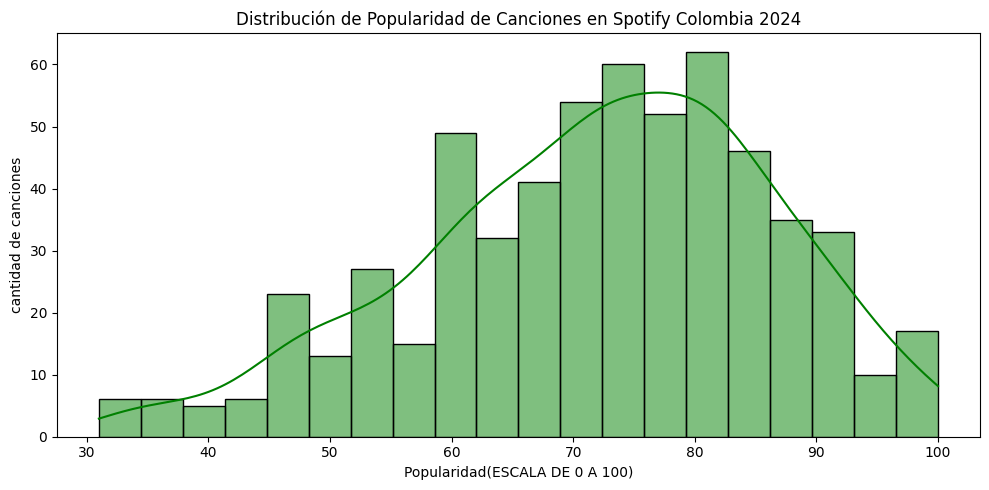

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='popularidad', bins=20, kde=True, color='green')
plt.title('Distribución de Popularidad de Canciones en Spotify Colombia 2024')
plt.xlabel('Popularidad(ESCALA DE 0 A 100)')
plt.ylabel('cantidad de canciones')
plt.tight_layout()
plt.show()


### HISTOGRAMA

Es como un histograma suave para ver qué géneros tienden a tener canciones más o menos populares.

sns.kdeplot        → gráfico de densidad

data=df            → usa el DataFrame df

x="popularidad"    → analiza popularidad

hue="genero"       → separa por género musical

fill=True          → rellena las curvas

alpha=0.4          → transparencia

common_norm=False  → compara cada género por separado

<Axes: xlabel='popularidad', ylabel='Density'>

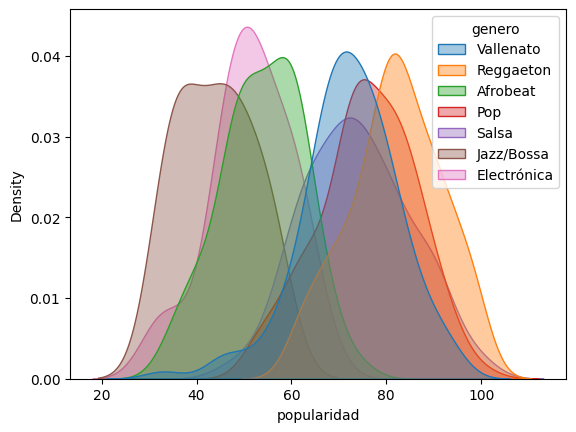

In [10]:
sns.kdeplot(
    data=df,
    x="popularidad",
    hue="genero" ,
    fill=True,
    alpha=0.4,
    common_norm=False
)


<h2>El tamaño de la caja es la historia.</h2>

<div style="display:flex; gap:20px;">

<div style="border:1px solid #1DB954; padding:15px; border-radius:10px; width:45%;">
<b>📦 Caja pequeña + mediana alta</b><br><br>
Rendimiento <span style="color:#1DB954;"><b>predecible y alto</b></span>, la apuesta más segura para Q4. El 50% centra de las canciones vive en un rango concentrado de popularidad alta.
</div>

<div style="border:1px solid red; padding:15px; border-radius:10px; width:45%;">
<b>📦 Caja grande</b><br><br>
Comportamiento <span style="color:red;"><b>inconsistente</b></span>. Puede tener hits excepcionales, pero también muchas fracasos. Lotería — puede salir muy bien o muy mal.
</div>

</div>

<br>

<div style="background-color:#111; padding:15px; border-radius:10px;">
<span style="color:orange;"><b>REGLA DE NEGOCIO</b></span><br><br>
Caja grande = alta variabilidad = riesgo de inversión.  
Un género con <span style="color:#1DB954;"><b>caja pequeña y mediana alta</b></span> es donde el director debería poner su dinero para un Q4 con resultados predecibles.
</div>

C:\Users\Ximena\AppData\Local\Temp\ipykernel_26124\332207328.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


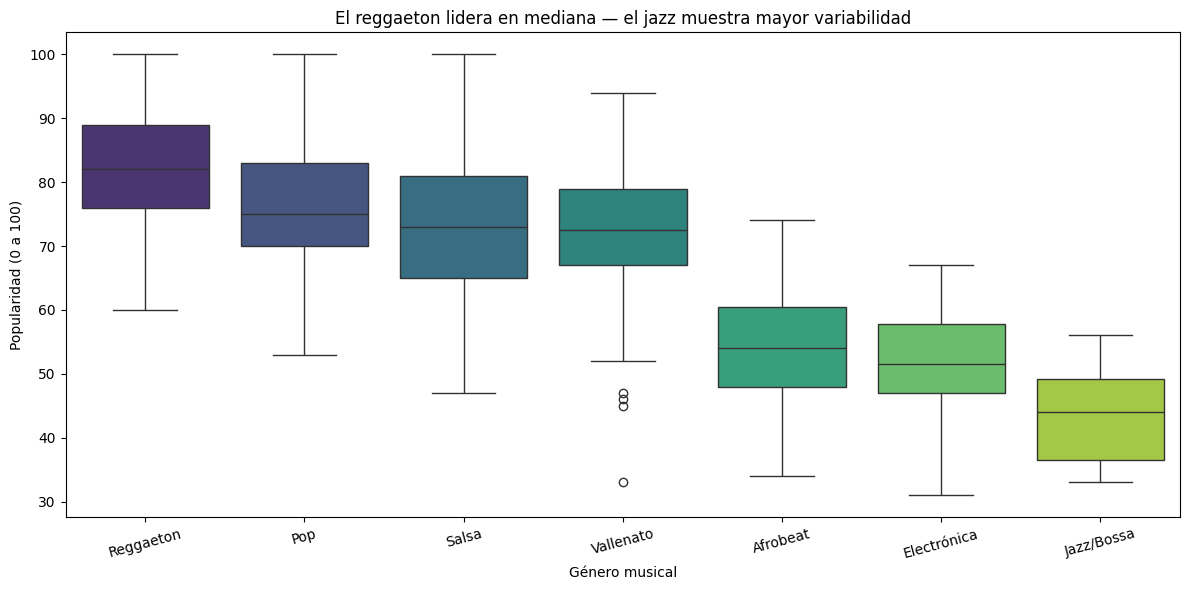

In [11]:
orden_generos = (df.groupby("genero")["popularidad"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="genero",
    y="popularidad",
    order=orden_generos,
    palette="viridis"
)

plt.title("El reggaeton lidera en mediana — el jazz muestra mayor variabilidad")
plt.xlabel("Género musical")
plt.ylabel("Popularidad (0 a 100)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()